# VSN+LSTM Model with Meta-Model and Volatility or Risk Parity Weighted

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from datetime import datetime
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import roc_auc_score
from joblib import Parallel, delayed
import seaborn as sns

In [2]:
df = pd.read_csv("merged_stock_with_text_features.csv")
print(df.columns.tolist())

['date', 'ticker', 'PX_HIGH', 'PX_LOW', 'PX_OPEN', 'PX_LAST', 'PX_VOLUME', 'PE_RATIO', 'PX_TO_BOOK_RATIO', 'PX_TO_SALES_RATIO', 'DAY_TO_DAY_TOT_RETURN_GROSS_DVDS', 'CUR_MKT_CAP', 'IVOL_DELTA', 'IVOL_IMPLIED_FORWARD', 'fwd_return_1d', 'fwd_return_5d', 'fwd_return_20d', 'fwd_return_40d', 'daily_rf_return', 'vrp_std_250', 'PE_RATIO_signal_60', 'PX_TO_BOOK_RATIO_signal_60', 'PX_TO_SALES_RATIO_signal_60', 'PX_LAST_EWMA_signal_span60', 'crossover_signal', 'classic_breakout_60_20', 'cont_breakout_mu60_lam5_d0.9', 'RSI_signal_60', 'momentum_60d', 'momentum_20d', 'momentum_200d', 'momentum_220d', 'momentum_80d', 'macd_signal_15_60', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5', 'pca_6', 'pca_7', 'pca_8', 'pca_9', 'pca_10']


In [3]:
# Select specific columns to keep
feature_cols = [
    'vrp_std_250', 'PE_RATIO_signal_60', 'PX_TO_BOOK_RATIO_signal_60',
    'PX_TO_SALES_RATIO_signal_60', 'PX_LAST_EWMA_signal_span60', 'crossover_signal',
    'classic_breakout_60_20', 'cont_breakout_mu60_lam5_d0.9', 'RSI_signal_60',
    'momentum_60d', 'momentum_20d', 'momentum_200d', 'momentum_220d', 'momentum_80d',
    'macd_signal_15_60',
    'pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5',
    'pca_6', 'pca_7', 'pca_8', 'pca_9', 'pca_10'
]

# Add essential metadata and label columns
selected_cols = ['date', 'ticker', 'fwd_return_40d'] + feature_cols

# Keep only the selected columns
df = df[selected_cols]

print(df.head())

print(df.columns.tolist())

         date ticker  fwd_return_40d  vrp_std_250  PE_RATIO_signal_60  \
0  2012-01-03    ACN        0.127093    -0.256872            0.833333   
1  2012-01-04    ACN        0.125999    -0.284793            0.866667   
2  2012-01-05    ACN        0.172557    -0.251431            1.000000   
3  2012-01-06    ACN        0.147204    -0.314582            1.000000   
4  2012-01-09    ACN        0.152099    -0.244131            1.000000   

   PX_TO_BOOK_RATIO_signal_60  PX_TO_SALES_RATIO_signal_60  \
0                    0.766667                     0.833333   
1                    0.800000                     0.866667   
2                    1.000000                     1.000000   
3                    1.000000                     1.000000   
4                    1.000000                     1.000000   

   PX_LAST_EWMA_signal_span60  crossover_signal  classic_breakout_60_20  ...  \
0                    0.048264          0.045307                    -0.0  ...   
1                    0.04710

## 1. Input Vector Construction

The goal is to construct 3 dimensions input tensors from panel data for LSTM. Each sample corresponds to a specific stock on a specific date, using the past 5 days of features as input to predict the forward 40-day return (`fwd_return_40d`).

---

## Step 1: Feature Definition

Two types of features are used:

- **Scalar features (`scalar_cols`)**: Includes valuation ratios (e.g., PE, PB, PS), momentum signals (20d, 60d, 200d, etc.), breakout indicators, technical signals like RSI and MACD, and volatility risk premium.

- **PCA features (`pca_cols`)**: The first 10 principal components extracted from FINBERT PCA embedding with daily sentiment strength scaling, capturing key information of stock daily news.

These are combined into a single feature list:

$$
\text{feature\_cols} = \text{scalar\_cols} + \text{pca\_cols}
$$

Total dimension per time step: 25

---

## Step 2: Sequence Window Construction

A fixed sequence length of 5 is used:

$$
\text{sequence\_length} = 5
$$

This means each input vector for the model will be of shape $5 \times 25$, representing a rolling window of past 5 days of features for a given stock.

---

## Step 3: Construct on each stock

For each `ticker` in the dataset:

1. Sort the data.
2. Fill missing feature values with 0 to ensure numerical stability.
3. Extract:
   - `feats`: feature matrix of shape $(T, 25)$
   - `targets`: forward return target vector of shape $(T,)$
   - `dates`: array of date

---

## Step 4: Sample Construction Per Day

For each time step $i$ in the stock’s history:

- Skip the sample if `targets[i]` is NaN.
- Construct the input sequence:
  - If $i < 5$: pad the missing days with zeros on top.
  - If $i \geq 5$: take the previous 5 rows directly.

This results in an input matrix:

$$
X_i \in \mathbb{R}^{5 \times 25}
$$

The corresponding label is:

$$
y_i = \text{fwd\_return\_40d}[i]
$$

The associated metadata is:

$$
\text{meta}_i = (\text{ticker}, \text{date}[i])
$$

---

## Step 5: Final Dataset

After processing all tickers and all time steps:

- **Input tensor**:

  $$
  X \in \mathbb{R}^{N \times 5 \times 25}
  $$

- **Label vector**:

  $$
  y \in \mathbb{R}^N
  $$

- **Metadata list**:

  A list of length $N$ containing `(ticker, date)` pairs.

---

In [4]:
# 1) Define feature lists in the correct order
scalar_cols = [
    'vrp_std_250', 'PE_RATIO_signal_60', 'PX_TO_BOOK_RATIO_signal_60',
    'PX_TO_SALES_RATIO_signal_60', 'PX_LAST_EWMA_signal_span60',
    'crossover_signal', 'classic_breakout_60_20',
    'cont_breakout_mu60_lam5_d0.9', 'RSI_signal_60',
    'momentum_60d', 'momentum_20d', 'momentum_200d',
    'momentum_220d', 'momentum_80d', 'macd_signal_15_60'
]
pca_cols = [f'pca_{i}' for i in range(1, 11)]
feature_cols = scalar_cols + pca_cols

sequence_length = 5
target_col = 'fwd_return_40d'

X_list, y_list, meta_list = [], [], []

for ticker, group in df.groupby('ticker'):
    group = group.sort_values('date').reset_index(drop=True)
    feats = group[feature_cols].fillna(0.0).values      # shape: (T, 25)
    targets = group[target_col].values                  # shape: (T,)
    dates = group['date'].values

    for i in range(len(group)):
        if np.isnan(targets[i]):
            continue

        # build window of past `sequence_length` days, pad with zeros if i < sequence_length
        if i < sequence_length:
            pad = np.zeros((sequence_length - i, feats.shape[1]), dtype=float)
            window = np.vstack([pad, feats[:i]])          # shape: (5, 25)
        else:
            window = feats[i-sequence_length:i]           # shape: (5, 25)

        X_list.append(window)
        y_list.append(targets[i])
        meta_list.append((ticker, dates[i]))

# stack into arrays
X = np.stack(X_list)   # shape: (N, 5, 25)
y = np.array(y_list)   # shape: (N,)
meta = meta_list       # list of length N

In [5]:
print("Feature column order:")
for i, col in enumerate(feature_cols):
    print(f"{i+1:02d}: {col}")

Feature column order:
01: vrp_std_250
02: PE_RATIO_signal_60
03: PX_TO_BOOK_RATIO_signal_60
04: PX_TO_SALES_RATIO_signal_60
05: PX_LAST_EWMA_signal_span60
06: crossover_signal
07: classic_breakout_60_20
08: cont_breakout_mu60_lam5_d0.9
09: RSI_signal_60
10: momentum_60d
11: momentum_20d
12: momentum_200d
13: momentum_220d
14: momentum_80d
15: macd_signal_15_60
16: pca_1
17: pca_2
18: pca_3
19: pca_4
20: pca_5
21: pca_6
22: pca_7
23: pca_8
24: pca_9
25: pca_10


## 2. LSTMWithVSN: Model Structure

This model is designed for time series prediction. It takes in both numerical features and text features, combines them using a **Variable Selection Network (VSN)**, and uses an LSTM to learn from their sequence over time. The final output is a predicted value for each sample.

---

## Part 1: `VSNBlock` – Feature Combination with Attention

### Process

`VSNBlock` takes in two types of features:
- **Scalar features**: single-value inputs like momentum, valuation ratios, technical indicators, etc.
- **Text embeddings**: multi-value inputs from text (e.g., news), already converted into vectors.

It transforms each feature into the same hidden size, uses an attention mechanism to decide which features are more important, and combines them into one feature vector per time step.

### Components

- `scalar_encoders`: A list of linear layers. Each scalar feature goes through its own linear transformation.
- `text_encoder`: A linear layer that takes the **text embedding plus 10 PCA components** as input and transforms them to dimension `D_e`.
- `grn`: A shared network with non-linearity, used to process both scalar and text features.
- `dropout`: Regularization layer to prevent overfitting.
- `attn`: A linear layer that gives each feature an importance score.
- `last_attn_weights`: Stores the attention weights from the latest forward pass.

### Forward Process

Input:
- `x_scalars`: Shape (B, T, S), where B = batch size, T = time steps, S = number of scalar features
- `x_text`: Shape (B, T, D), where D = text embedding size

Steps:
1. Each scalar feature is processed individually:
   - Linear layer → GRN → Dropout
2. The text input is also processed:
   - Linear layer → GRN → Dropout
3. All transformed features are stacked together: shape becomes (B, T, F, D_e), where F = number of features and D_e = hidden size
4. Attention scores are computed for each feature:
   - Apply softmax over the feature axis
5. Weighted sum of features is taken to get the final output:
   - Output shape: (B, T, D_e)

---

## Part 2: `LSTMWithVSN` – Full Model for Prediction

### process

This model uses:
- `VSNBlock` to combine features at each time step
- LSTM to learn patterns over time
- A final linear layer to make predictions

### Components

- `vsn`: The VSN module from above
- `lstm`: The LSTM layer that models sequences
- `dropout`: Used after LSTM to reduce overfitting
- `output_layer`: Final linear layer outputs prediction for forward return

### Forward Process

Input:
- `x`: Tensor with shape (B, T, S + D), where S = number of scalar features, D = text feature size

Steps:
1. Split input into:
   - `x_scalars`: (B, T, S)
   - `x_text`: (B, T, D)
2. Pass through VSN to get fused features: (B, T, D_e)
3. Pass through LSTM to model time dependencies: output shape (B, T, lstm_hidden)
4. Take the last time step’s output: (B, lstm_hidden)
5. Apply dropout and then pass through the final output layer
6. Get final prediction: shape (B,)

---

In [6]:
# VSNBlock: Feature fusion + attention
class VSNBlock(nn.Module):
    def __init__(self, num_scalars: int, text_dim: int, D_e: int, dropout_prob: float = 0.2):
        super().__init__()
        # Linear encoders for each scalar feature
        self.scalar_encoders = nn.ModuleList([
            nn.Linear(1, D_e) for _ in range(num_scalars)
        ])
        # Linear encoder for the text embedding
        self.text_encoder = nn.Linear(text_dim, D_e)

        # Gated Residual Network (GRN) for transformation
        self.grn = nn.Sequential(
            nn.Linear(D_e, D_e),
            nn.ReLU(),
            nn.Linear(D_e, D_e)
        )

        # Dropout layer
        self.dropout = nn.Dropout(dropout_prob)

        # Attention scorer
        self.attn = nn.Linear(D_e, 1)

        # Store attention weights externally 
        self.last_attn_weights = None

    def forward(self, x_scalars: torch.Tensor, x_text: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x_scalars: (B, T, num_scalars)
            x_text:    (B, T, text_dim)
        Returns:
            v:        (B, T, D_e) fused feature vector
        """
        B, T, _ = x_scalars.size()
        scalar_reprs = []

        # Apply GRN + dropout to each scalar
        for idx, encoder in enumerate(self.scalar_encoders):
            xi = x_scalars[..., idx].unsqueeze(-1)    # (B, T, 1)
            zi = self.grn(encoder(xi))                # (B, T, D_e)
            zi = self.dropout(zi)
            scalar_reprs.append(zi)

        # Apply GRN + dropout to text features
        text_repr = self.grn(self.text_encoder(x_text))  # (B, T, D_e)
        text_repr = self.dropout(text_repr)
        scalar_reprs.append(text_repr)

        # Stack → (B, T, num_features, D_e)
        Z = torch.stack(scalar_reprs, dim=2)

        # Attention weights → (B, T, num_features, 1)
        scores = self.attn(Z).squeeze(-1)                  # (B, T, num_features)
        weights = F.softmax(scores, dim=-1).unsqueeze(-1)  # (B, T, num_features, 1)

        # Store
        self.last_attn_weights = weights.detach().cpu()

        # Weighted sum → (B, T, D_e)
        v = (weights * Z).sum(dim=2)
        return v

# LSTMWithVSN: Full model for sequence prediction
class LSTMWithVSN(nn.Module):
    def __init__(self, num_scalars: int, text_dim: int, D_e: int, lstm_hidden: int,
                 lstm_layers: int = 2, dropout_prob: float = 0.3):
        super().__init__()

        # VSN for feature selection & fusion
        self.vsn = VSNBlock(
            num_scalars=num_scalars,
            text_dim=text_dim,
            D_e=D_e,
            dropout_prob=dropout_prob  # dropout
        )

        # LSTM for temporal modeling
        self.lstm = nn.LSTM(
            input_size=D_e,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout_prob if lstm_layers > 1 else 0.0
        )

        # Dropout after LSTM
        self.dropout = nn.Dropout(dropout_prob)

        # Final prediction layer
        self.output_layer = nn.Linear(lstm_hidden, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Tensor (B, T, num_scalars + text_dim)
        Returns:
            preds: Tensor (B,)
        """
        num_scalars = len(self.vsn.scalar_encoders)
        x_scalars = x[:, :, :num_scalars]     # (B, T, num_scalars)
        x_text    = x[:, :, num_scalars:]     # (B, T, text_dim)

        # Feature fusion
        vsn_out = self.vsn(x_scalars, x_text)  # (B, T, D_e)

        # LSTM modeling
        lstm_out, _ = self.lstm(vsn_out)       # (B, T, lstm_hidden)

        # Use last time step
        last_hidden = lstm_out[:, -1, :]       # (B, lstm_hidden)
        last_hidden = self.dropout(last_hidden)

        preds = self.output_layer(last_hidden).squeeze(-1)  # (B,)
        return preds

## 3. Rolling Time-Based Split: Explanation and Justification

This method performs data splitting based on fixed time windows to construct training, validation, and test sets. It is specifically designed for time-series prediction tasks.

---

### Purpose of This Setup

For each test year, the data is split into three non-overlapping periods:
- Training: the previous 5 years
- Validation: the following 6 months (included in train set)
- Test: the entire target year

Each split strictly follow the time axis to prevent using any information from the future in the training or validation sets.

---

### Why Rolling Forward Cross-Validation Is Not Used

Rolling forward cross-validation is a common method for time series model selection. It trains the model on a growing window of past data and tests it on the next time period. This approach is useful when the model is simple, training is fast, and many rounds of tuning are needed.

However, for deep learning models such as LSTM, this method is often too slow and difficult to use in practice. Each fold requires training a full neural network, which takes a lot of time and computing power. Unlike simple models like Lasso, neural networks do not train quickly, and their results can vary due to random starting points. This makes cross-validation less reliable and more costly.

Also, LSTM models already need a lot of tuning for things like network size, sequence length, learning rate, and dropout. In many cases, using one fixed training, validation, and test split is enough to measure performance, as long as the time order is correct and no future data is included in training.

For this reason, the model is evaluated using a fixed time-based split instead of rolling cross-validation.

---

In [7]:
def to_date(s):
    return pd.to_datetime(s)

# Define fixed train (5 years), validation (0.5 year), and test (1 year) periods
time_splits = {
    2017: {
        'train': (to_date("2012-01-01"), to_date("2016-06-30")),
        'val':   (to_date("2016-07-01"), to_date("2016-12-31")),
        'test':  (to_date("2017-01-01"), to_date("2017-12-31")),
    },
    2018: {
        'train': (to_date("2013-01-01"), to_date("2017-06-30")),
        'val':   (to_date("2017-07-01"), to_date("2017-12-31")),
        'test':  (to_date("2018-01-01"), to_date("2018-12-31")),
    },
    2019: {
        'train': (to_date("2014-01-01"), to_date("2018-06-30")),
        'val':   (to_date("2018-07-01"), to_date("2018-12-31")),
        'test':  (to_date("2019-01-01"), to_date("2019-12-31")),
    },
    2020: {
        'train': (to_date("2015-01-01"), to_date("2019-06-30")),
        'val':   (to_date("2019-07-01"), to_date("2019-12-31")),
        'test':  (to_date("2020-01-01"), to_date("2020-12-31")),
    }
}

def get_indices_by_date(meta, start, end):
    """
    Return list of indices in meta whose date is between [start, end].
    
    Args:
        meta: List of (ticker, date) tuples
        start: Start date (inclusive)
        end: End date (inclusive)
        
    Returns:
        List of index positions satisfying the date range condition
    """
    return [
        i for i, (_, d) in enumerate(meta)
        if pd.Timestamp(start) <= pd.Timestamp(d) <= pd.Timestamp(end)
    ]

def build_splits(X, y, meta, year, time_splits):
    """
    Build training, validation, and test index splits for a given test year.
    
    Args:
        X: Feature matrix
        y: Target values
        meta: List of (ticker, date) tuples
        year: The test year
        time_splits: Dictionary containing train/val/test date ranges

    Returns:
        Dictionary with train/val/test indices
    """
    split = time_splits[year]

    train_idx = get_indices_by_date(meta, *split['train'])
    val_idx   = get_indices_by_date(meta, *split['val'])
    test_idx  = get_indices_by_date(meta, *split['test'])

    return {
        'train_idx': train_idx,
        'val_idx': val_idx,
        'test_idx': test_idx
    }

## 4. LSTMVSNDataset: PyTorch Dataset for LSTM + VSN

This code defines a custom `Dataset` class for training the LSTM + VSN model in PyTorch. It wraps input features and labels into a structure compatible with PyTorch's `DataLoader`.

---

### Purpose

The dataset is designed to feed 3 dimension tensors (for sequences) or 2 dimension tensors (for non-sequential input) into models during training and evaluation.

---

### Class: `LSTMVSNDataset`

#### Inputs
- `X`: A NumPy array of shape:
  - `[N, D]` for non-sequential input (flat features)
  - or `[N, T, D]` for sequential input (sequences of length `T`)
- `y`: A NumPy array of shape `[N]`, containing the corresponding target values

#### Internals
- `X` and `y` are converted to PyTorch tensors of type `float32` for compatibility with neural networks.

#### Methods
- `__len__`: Returns the total number of samples
- `__getitem__`: Retrieves the `i`-th input-output pair: `X[i], y[i]`

---

In [8]:
# Construct PyTorch Dataset for LSTM + VSN training
class LSTMVSNDataset(Dataset):
    def __init__(self, X, y):
        """
        Args:
            X: numpy array of shape [num_samples, feature_dim] or [num_samples, seq_len, feature_dim]
            y: numpy array of shape [num_samples]
        """
        # Convert input data to PyTorch tensors
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        # Return total number of samples
        return len(self.y)

    def __getitem__(self, idx):
        # Retrieve the feature and label at a specific index
        return self.X[idx], self.y[idx]

# Create Dataset and DataLoader
dataset = LSTMVSNDataset(X, y)
dataloader = DataLoader(dataset, batch_size=64, shuffle=False)

## 5. LSTM + VSN Training and Evaluation Pipeline

This code defines the full training, validation, testing, and evaluation pipeline for an LSTM + VSN model across multiple test years. The process includes model training, grid search, saving attention weights, and exporting predictions.

---

### 1. Model Training Function: `train_model`

Trains the model using mean squared error (MSE) as the loss function and the Adam optimizer.

- Inputs:
  - `model`: a PyTorch model (LSTMWithVSN)
  - `train_X`, `train_y`: training data
  - `num_epochs`, `batch_size`, `learning_rate`: training setup

- Training:
  - Iterates through epochs
  - Performs forward pass, computes loss, backpropagates, and updates weights
  - Uses mini-batch training via `DataLoader`

---

### 2. Main Loop Over Test Years

The training loop is repeated for each test year from 2017 to 2020.

#### Step 1: Build Time-Based Splits

For a given year, construct:
- Training set
- Validation set
- Test set

using predefined time intervals.

#### Step 2: Grid Search on Validation Set

- Hyperparameters searched:
  - `D_e` (VSN hidden size)
  - `lstm_hidden` (LSTM hidden dimension)
  - `lr` (learning rate)
  
- For each setup:
  - Initialize and train the model on the training set
  - Evaluate predictions on the validation set
  - Compute Spearman rank correlation (IC)
  - Track the best configuration based on validation IC

#### Step 3: Train Final Model on Train + Val

- Merge training and validation sets
- Retrain the model using the best hyperparameter set

#### Step 3.5: Predict on Training Set

- Generate predictions on the original training set
- Store `(ticker, date, true, pred)` for later analysis

#### Step 4: Save Model

- Save model weights using `torch.save`

#### Step 5: Predict on Test Set

- Generate predictions
- Extract attention weights from the VSN block
- Store attention scores from the last time step
- Save attention weights with `ticker`, `date`, and `test_year` to CSV

#### Step 6: Evaluate Model on Test Set

- Calculate test MSE and test IC
- Store best hyperparameter set and test performance in a result table

---

### 3. Save Outputs

Three CSV files are saved:
- `lstm_vsn_best_config_results.csv`: test-year-wise hyperparameter and performance summary
- `lstm_vsn_train_test_predictions.csv`: full predictions with metadata
- Split versions: `lstm_vsn_train_predictions.csv` and `lstm_vsn_test_predictions.csv`

---


In [9]:
'''
# Define train_model with learning rate support
def train_model(model, train_X, train_y, num_epochs=20, batch_size=64, learning_rate=1e-3):
    dataset = LSTMVSNDataset(train_X, train_y)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    model.train()
    for epoch in range(num_epochs):
        total_loss = 0.0
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * X_batch.size(0)

    return model
    
# Main training loop over test years
config_results = []
all_preds = []

for year in tqdm([2017, 2018, 2019, 2020], desc="Test Years"):
    # Step 1: Build splits
    split = build_splits(X, y, meta, year, time_splits)

    train_X = X[split['train_idx']]
    train_y = y[split['train_idx']]
    val_X   = X[split['val_idx']]
    val_y   = y[split['val_idx']]
    test_X  = X[split['test_idx']]
    test_y  = y[split['test_idx']]

    # Step 2: Grid search on fixed train/val split
    param_grid = {
        'D_e': [16, 32],
        'lstm_hidden': [16, 32],
        'lr': [1e-3, 5e-4, 1e-4]
    }

    best_config = None
    best_val_ic = -np.inf
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    for D_e in param_grid['D_e']:
        for lstm_hidden in param_grid['lstm_hidden']:
            for lr in param_grid['lr']:
                model = LSTMWithVSN(
                    num_scalars=15, text_dim=10,
                    D_e=D_e, lstm_hidden=lstm_hidden, dropout_prob=0.2
                )
                model = train_model(
                    model, train_X, train_y,
                    num_epochs=20,
                    learning_rate=lr
                )

                model.eval()
                with torch.no_grad():
                    val_preds = model(torch.tensor(val_X, dtype=torch.float32).to(device)).cpu().numpy()
                val_ic, _ = spearmanr(val_preds, val_y)

                if val_ic > best_val_ic:
                    best_val_ic = val_ic
                    best_config = {
                        'D_e': D_e,
                        'lstm_hidden': lstm_hidden,
                        'lr': lr
                    }

    # Step 3: Train final model using best config on train+val set
    final_train_X = np.concatenate([train_X, val_X], axis=0)
    final_train_y = np.concatenate([train_y, val_y], axis=0)

    model = LSTMWithVSN(
        num_scalars=15, text_dim=10,
        D_e=best_config['D_e'],
        lstm_hidden=best_config['lstm_hidden'],
        dropout_prob=0.2
    )
    trained_model = train_model(
        model, final_train_X, final_train_y,
        num_epochs=20,
        learning_rate=best_config['lr']
    )

    # Step 3.5: Predict on train set
    trained_model.eval()
    with torch.no_grad():
        train_preds = trained_model(torch.tensor(train_X, dtype=torch.float32).to(device)).cpu().numpy()

    for i, idx in enumerate(split['train_idx']):
        ticker, date = meta[idx]
        all_preds.append({
            'test_year': year,
            'dataset': 'train',
            'ticker': ticker,
            'date': date,
            'true': train_y[i],
            'pred': train_preds[i]
        })

    # Step 4: Save model
    torch.save(trained_model.state_dict(), f"best_model_{year}.pt")

    # Step 5: Predict on test set
    with torch.no_grad():
        test_tensor = torch.tensor(test_X, dtype=torch.float32).to(device)
        test_preds = trained_model(test_tensor).cpu().numpy()

        # Step 5.1: Extract attention weights (shape: B, T, num_features, 1)
        attn_weights = trained_model.vsn.last_attn_weights

        # Only keep attention at last time step → shape: (B, num_features)
        last_attn = attn_weights[:, -1, :, 0].numpy()

        # Map to ticker/date
        meta_test = [meta[idx] for idx in split['test_idx']]
        attn_df = pd.DataFrame(last_attn, columns=[f"feature_{i}" for i in range(last_attn.shape[1])])
        attn_df['ticker'] = [t for t, d in meta_test]
        attn_df['date'] = [d for t, d in meta_test]
        attn_df['test_year'] = year

        attn_df.to_csv(f"attention_weights_{year}.csv", index=False)

    # Step 6: Evaluate test metrics
    test_mse = np.mean((test_preds - test_y) ** 2)
    test_ic, _ = spearmanr(test_preds, test_y)

    config_results.append({
        'test_year': year,
        'best_D_e': best_config['D_e'],
        'best_lstm_hidden': best_config['lstm_hidden'],
        'best_lr': best_config['lr'],
        'best_val_ic': best_val_ic,
        'test_ic': test_ic,
        'test_mse': test_mse
    })

    for i, idx in enumerate(split['test_idx']):
        ticker, date = meta[idx]
        all_preds.append({
            'test_year': year,
            'dataset': 'test',
            'ticker': ticker,
            'date': date,
            'true': test_y[i],
            'pred': test_preds[i]
        })

# Save final outputs
config_df = pd.DataFrame(config_results)
config_df.to_csv("lstm_vsn_best_config_results.csv", index=False)

pred_df = pd.DataFrame(all_preds)
pred_df.to_csv("lstm_vsn_train_test_predictions.csv", index=False)
pred_df[pred_df['dataset'] == 'train'].to_csv("lstm_vsn_train_predictions.csv", index=False)
pred_df[pred_df['dataset'] == 'test'].to_csv("lstm_vsn_test_predictions.csv", index=False)
'''

'\n# Define train_model with learning rate support\ndef train_model(model, train_X, train_y, num_epochs=20, batch_size=64, learning_rate=1e-3):\n    dataset = LSTMVSNDataset(train_X, train_y)\n    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)\n\n    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n    model = model.to(device)\n\n    criterion = nn.MSELoss()\n    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)\n\n    model.train()\n    for epoch in range(num_epochs):\n        total_loss = 0.0\n        for X_batch, y_batch in dataloader:\n            X_batch, y_batch = X_batch.to(device), y_batch.to(device)\n\n            preds = model(X_batch)\n            loss = criterion(preds, y_batch)\n\n            optimizer.zero_grad()\n            loss.backward()\n            optimizer.step()\n\n            total_loss += loss.item() * X_batch.size(0)\n\n    return model\n    \n# Main training loop over test years\nconfig_results = [

## 6. Evaluation and Visualization of LSTM + VSN Results

This section includes visualizations for model performance and attention weights across test years (2017–2020). It summarizes how the model performs and which features it pays attention to over time.

---

### 1. Test MSE by Year

The first plot shows the **Mean Squared Error (MSE)** on the test set for each year.

- X-axis: Test year
- Y-axis: MSE
- Lower MSE indicates better predictive accuracy

---

### 2. Test IC (Spearman Rank Correlation) by Year

The second plot shows the **Spearman Information Coefficient (IC)** between predicted and true returns.

- X-axis: Test year
- Y-axis: Spearman IC
- Measures whether the model ranks samples correctly
- Higher IC indicates better rank correlation with ground truth

---

### 3. Feature Attention Trend by Year (Heatmap)

This section analyzes how much attention the model pays to each feature across years.

#### Step 1: Load attention weights
- For each test year, read the saved attention weight CSV file
- Compute the average attention across all test samples

#### Step 2: Combine per-year averages
- Construct a DataFrame where:
  - Rows = years
  - Columns = mean attention per feature

#### Step 3: Rename features
- Replace generic `feature_0`, `feature_1`, ... with actual feature names:
  - Includes 15 scalar features and 1 text (or text+PCA) vector

#### Step 4: Plot heatmap
- A heatmap shows attention weights over years
- Each cell shows the average importance assigned to a feature in a given year

---

## Chart Analysis of LSTM + VSN Results

The results include three key visualizations:
1. Test MSE by Year  
2. Test IC by Year  
3. Attention Weights Heatmap by Year

Each plot provides insights into the model’s predictive performance and how feature importance shifts over time.

---

### 1. Test MSE by Year

**Observation:**
- MSE remains low and stable from 2017 to 2019.
- A sharp increase occurs in 2020.

**Interpretation:**
- The model performs consistently well until 2020.
- The large rise in error in 2020, this might reflect real-world shocks (COVID-19), which reduce the generalizability of models trained on past data.

---

### 2. Test IC (Spearman Correlation) by Year

**Observation:**
- IC increases from 2017 to 2019, peaking in 2019 (strongest rank correlation).
- A significant drop occurs in 2020, approaching zero.

**Interpretation:**
- The model becomes better at ranking return signals over time until 2019.
- In 2020, the rank-ordering ability drops, consistent with the MSE spike.
- This indicated that the **signal-to-noise ratio dropped**, or feature relationships with the target changed significantly in 2020.

---

### 3. Feature Attention Weights by Year (Heatmap)

**Observation:**
- **In 2019**, attention is heavily concentrated on a few features:
  - `momentum_200d`, `momentum_220d`, `momentum_80d`, `momentum_60d`
  - `text` (text + PCA combined input) reaches an unusually high weight of **0.233**
- In **other years**, attention is more evenly distributed across valuation, momentum, and technical signals.
- `classic_breakout_60_20`, `cont_breakout_mu60_lam5_d0.9`, and `PX_TO_SALES_RATIO_signal_60` receive very little attention in 2019.

**Interpretation:**
- The model shifts to rely more on **long-horizon momentum** and **text signals** in 2019, possibly due to their stronger predictive power that year.
- In 2020, attention redistributes again, indicating **feature instability** and potential **regime non-stationarity**.
- The spike in attention on `text` in 2019 indicates that textual signals (news sentiment or embeddings) became particularly useful that year.

---

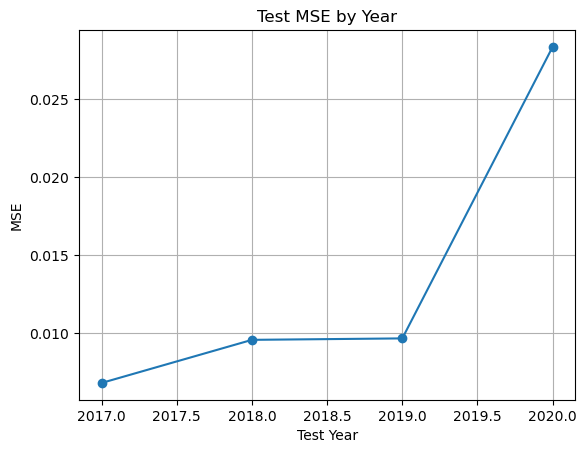

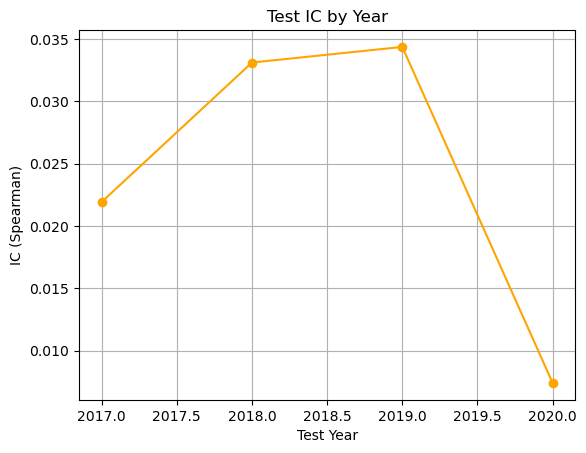

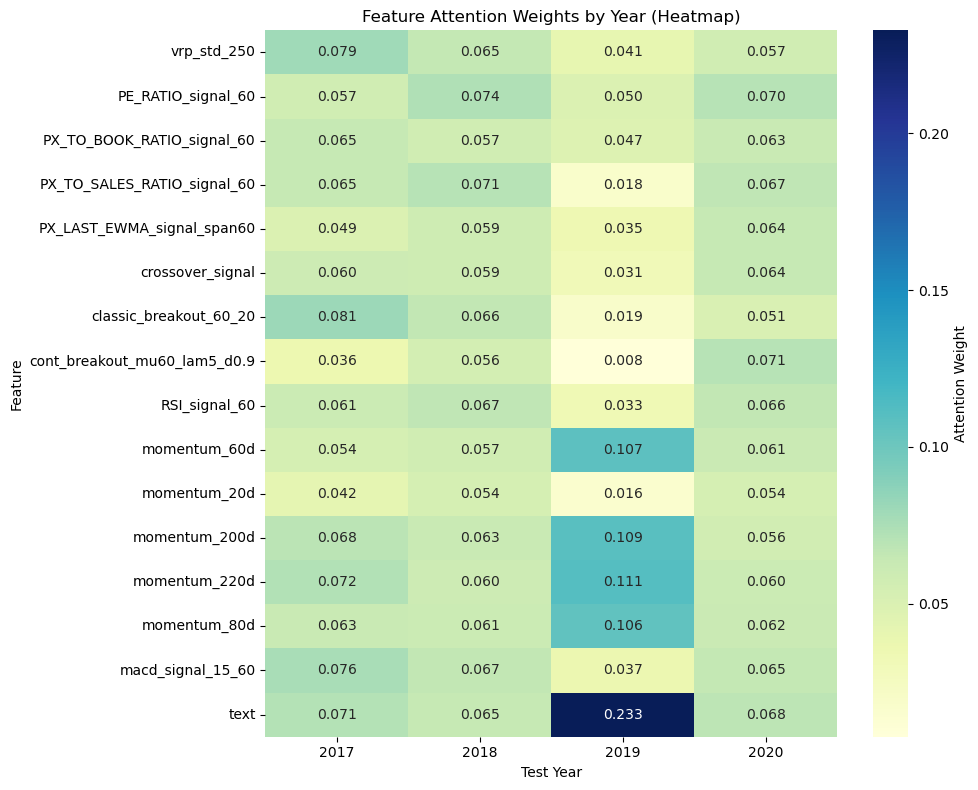

In [10]:
config_df = pd.read_csv('lstm_vsn_best_config_results.csv')
# Plot Test MSE by Year
plt.figure()
plt.plot(config_df['test_year'], config_df['test_mse'], marker='o')
plt.title("Test MSE by Year")
plt.xlabel("Test Year")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

# Plot Test IC by Year
plt.figure()
plt.plot(config_df['test_year'], config_df['test_ic'], marker='o', color='orange')
plt.title("Test IC by Year")
plt.xlabel("Test Year")
plt.ylabel("IC (Spearman)")
plt.grid(True)
plt.show()

# Plot Attention Trend by Year

# Step 1: Load attention weights for each year
years = [2017, 2018, 2019, 2020]
feature_means_by_year = []

for year in years:
    df = pd.read_csv(f"attention_weights_{year}.csv")
    feature_cols = [col for col in df.columns if col.startswith("feature_")]
    mean_weights = df[feature_cols].mean()
    mean_weights.name = year
    feature_means_by_year.append(mean_weights)

# Step 2: Combine into DataFrame
attn_trend_df = pd.DataFrame(feature_means_by_year)

# Step 3: Rename columns to actual feature names
attn_trend_df.columns = [
    'vrp_std_250',
    'PE_RATIO_signal_60',
    'PX_TO_BOOK_RATIO_signal_60',
    'PX_TO_SALES_RATIO_signal_60',
    'PX_LAST_EWMA_signal_span60',
    'crossover_signal',
    'classic_breakout_60_20',
    'cont_breakout_mu60_lam5_d0.9',
    'RSI_signal_60',
    'momentum_60d',
    'momentum_20d',
    'momentum_200d',
    'momentum_220d',
    'momentum_80d',
    'macd_signal_15_60',
    'text'
]

# Step 4: Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(attn_trend_df.T, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={"label": "Attention Weight"})
plt.title("Feature Attention Weights by Year (Heatmap)")
plt.xlabel("Test Year")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 7. Strategy Parameter Tuning (long short number and overlapping period)

This process searches for the best combination of trading parameters by running a grid search on the 2017 test data. The goal is to find a setting that reduces drawdowns while keeping returns stable.

#### Test Set Choice
The VSN+LSTM model was trained on data from 2012 to 2016. Using the same period to build long-short portfolios can lead to optimistic results. To avoid this, only 2017 is used here for strategy selection. The model does not see this year during training.

#### Parameter Grid

Three parameters are tested:

- `n_long`: number of stocks to buy (values from 1 to 5)
- `n_short`: number of stocks to short (values from 1 to 5)
- `rebalance_interval`: how often to rebalance the portfolio (values from 37 to 40 days)

There are $5 \times 5 \times 4 = 100$ total combinations.

#### Backtest Logic

For each combination:

1. Go through each rebalance date in 2017.
2. At each date:
   - Pick top `n_long` stocks with the highest predicted scores above 0.
   - Pick bottom `n_short` stocks with the lowest predicted scores below 0.
3. Calculate portfolio return:

$$
R_t = \frac{1}{n_{\text{long}}} \sum_{\text{long}} r_i - \frac{1}{n_{\text{short}}} \sum_{\text{short}} r_j
$$

Where $r_i$ and $r_j$ are forward 40-day returns.

4. Track daily return series $R_t$ and calculate:
   - **Sharpe ratio**:
     $$
     \text{Sharpe} = \frac{\text{mean}(R_t)}{\text{std}(R_t)}
     $$
   - **Maximum drawdown**:
     $$
     \text{MDD} = \min_t \left( \frac{C_t}{\max_{s \le t} C_s} - 1 \right)
     $$
     Where $C_t = \prod_{s \le t}(1 + R_s)$
   - **Cumulative return**:
     $$
     \text{Cumulative} = C_T - 1
     $$

#### Selection

The combination with the smallest drawdown is selected as the best. Sharpe ratio and total return are also recorded for reference.

### Grid Search Result on 2017 Validation

- **n_long**: 4  
- **n_short**: 2  
- **rebalance_interval**: 37 days  
- **Sharpe Ratio**: 1.1886  
- **Maximum Drawdown**: 0.00%  
- **Cumulative Return**: 20.63%

#### Observations

1. The portfolio value steadily increases throughout 2017, with no significant drawdown detected, indicating stable long-short performance under this parameter set.
2. A Sharpe ratio above 1 indicates strong risk-adjusted returns relative to the volatility of the strategy.
3. The cumulative return of approximately 20.6% over one year shows that the combination of 4 long and 2 short positions, with a 37-day rebalance cycle, achieves a favorable trade-off between return and risk.


In [11]:
def compute_metrics(daily_returns):
    cumulative = (1 + daily_returns).cumprod()
    sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252 / 40) if daily_returns.std() > 0 else 0.0
    peak = cumulative.cummax()
    mdd = (cumulative / peak - 1).min()
    return {
        'sharpe': sharpe,
        'mdd': mdd,
        'cumulative_return': cumulative.iloc[-1] - 1
    }

def backtest_fwd40_only(pred_df, n_long, n_short, rebalance_interval=20, test_year=2017):
    df = pred_df[
        (pred_df['dataset'] == 'test') &
        (pred_df['test_year'] == test_year)
    ].copy()

    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(['date', 'ticker'])

    all_dates = sorted(df['date'].unique())
    rebal_dates = all_dates[::rebalance_interval]

    pnl_by_date = {}

    for reb_date in rebal_dates:
        day_data = df[df['date'] == reb_date]

        long_pool = day_data[day_data['pred'] > 0].nlargest(n_long, 'pred')
        short_pool = day_data[day_data['pred'] < 0].nsmallest(n_short, 'pred')

        long_ret = long_pool['true'].mean() if not long_pool.empty else 0.0
        short_ret = short_pool['true'].mean() if not short_pool.empty else 0.0

        net_ret = long_ret - short_ret
        pnl_by_date[reb_date] = net_ret

    pnl_series = pd.Series(pnl_by_date).sort_index()
    metrics = compute_metrics(pnl_series)
    return pnl_series, metrics

Best configuration minimizing MDD:
  n_long:             4
  n_short:            2
  rebalance_interval: 37 days
  Sharpe Ratio:       2.9833
  Max Drawdown:       0.00%
  Cumulative Return:  20.63%


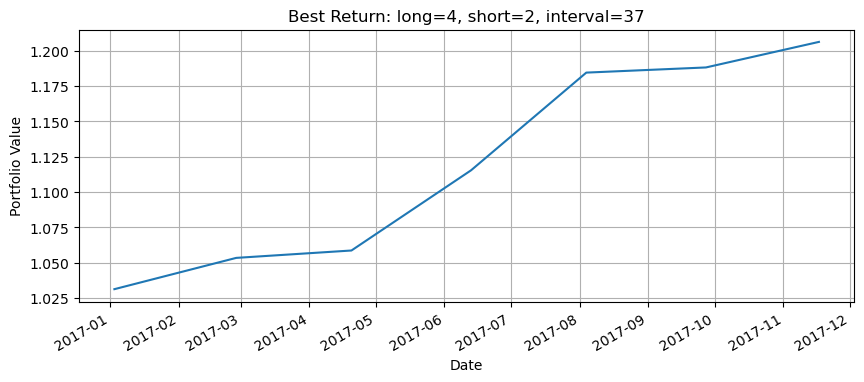

In [12]:
# Load prediction
pred_df = pd.read_csv("lstm_vsn_train_test_predictions.csv")

results = []
returns_by_combo = {}

for rebalance_interval in range(37, 41):
    for n_long in range(1, 6):
        for n_short in range(1, 6):
            pnl, metrics = backtest_fwd40_only(
                pred_df,
                n_long=n_long,
                n_short=n_short,
                rebalance_interval=rebalance_interval,
                test_year=2017
            )
            results.append({
                'n_long': n_long,
                'n_short': n_short,
                'rebalance_interval': rebalance_interval,
                'sharpe': metrics['sharpe'],
                'mdd': metrics['mdd'],
                'cumulative_return': metrics['cumulative_return']
            })
            returns_by_combo[(n_long, n_short, rebalance_interval)] = pnl

# Find best config by MDD
results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df['mdd'].idxmax()]

# Print best config
print("Best configuration minimizing MDD:")
print(f"  n_long:             {int(best_row['n_long'])}")
print(f"  n_short:            {int(best_row['n_short'])}")
print(f"  rebalance_interval: {int(best_row['rebalance_interval'])} days")
print(f"  Sharpe Ratio:       {best_row['sharpe']:.4f}")
print(f"  Max Drawdown:       {best_row['mdd']:.2%}")
print(f"  Cumulative Return:  {best_row['cumulative_return']:.2%}")

# Plot best cumulative return
best_combo = (
    int(best_row['n_long']),
    int(best_row['n_short']),
    int(best_row['rebalance_interval'])
)
best_ret_series = returns_by_combo[best_combo]

plt.figure(figsize=(10, 4))
(1 + best_ret_series).cumprod().plot()
plt.title(f"Best Return: long={best_combo[0]}, short={best_combo[1]}, interval={best_combo[2]}")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.show()

## 8. Test Period Performance (2018–2020) with Best Parameters

The best configuration found on 2017 data was applied to the test set from 2018 to 2020. The key performance metrics are as follows:

- **n_long**: 4  
- **n_short**: 2  
- **rebalance_interval**: 37 days  
- **Sharpe Ratio**: 0.2105  
- **Maximum Drawdown**: -35.86%  
- **Cumulative Return**: 38.18%

#### Observations

1. The portfolio achieved a total cumulative return of over 38% during the test period, indicating that the signal maintained positive performance when applied out-of-sample.
2. The Sharpe ratio is significantly lower than during validation, indicating weaker risk-adjusted performance.
3. A maximum drawdown of nearly 36% indicates substantial downside risk, which became more significantly in late 2020 (model lose efficacy in Covid-19 period).

Test 2018–2020 Performance with Best Config:
  n_long:             4
  n_short:            2
  rebalance_interval: 37 days
  Sharpe Ratio:       0.5285
  Max Drawdown:       -35.86%
  Cumulative Return:  38.18%


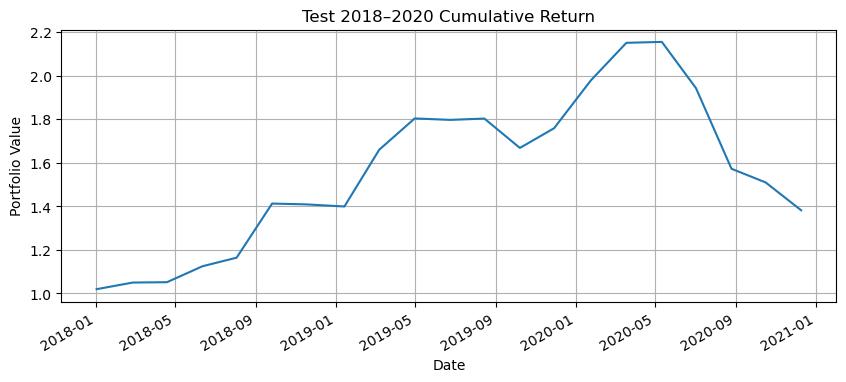

In [13]:
# Backtest on 2018–2020 using best config
def backtest_fwd40_only_range(pred_df, n_long, n_short, rebalance_interval, start_year=2018, end_year=2020):
    df = pred_df[
        (pred_df['dataset'] == 'test') &
        (pred_df['test_year'] >= start_year) &
        (pred_df['test_year'] <= end_year)
    ].copy()

    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(['date', 'ticker'])

    all_dates = sorted(df['date'].unique())
    rebal_dates = all_dates[::rebalance_interval]

    pnl_by_date = {}

    for reb_date in rebal_dates:
        day_data = df[df['date'] == reb_date]

        long_pool = day_data[day_data['pred'] > 0].nlargest(n_long, 'pred')
        short_pool = day_data[day_data['pred'] < 0].nsmallest(n_short, 'pred')

        long_ret = long_pool['true'].mean() if not long_pool.empty else 0.0
        short_ret = short_pool['true'].mean() if not short_pool.empty else 0.0

        net_ret = long_ret - short_ret
        pnl_by_date[reb_date] = net_ret

    pnl_series = pd.Series(pnl_by_date).sort_index()
    metrics = compute_metrics(pnl_series)
    return pnl_series, metrics

# Apply best config
best_n_long = 4
best_n_short = 2
best_rebal_interval = 37

test_ret_2018_2020, test_metrics_2018_2020 = backtest_fwd40_only_range(
    pred_df,
    n_long=best_n_long,
    n_short=best_n_short,
    rebalance_interval=best_rebal_interval,
    start_year=2018,
    end_year=2020
)

# Print metrics

print("Test 2018–2020 Performance with Best Config:")
print(f"  n_long:             {best_n_long}")
print(f"  n_short:            {best_n_short}")
print(f"  rebalance_interval: {best_rebal_interval} days")
print(f"  Sharpe Ratio:       {test_metrics_2018_2020['sharpe']:.4f}")
print(f"  Max Drawdown:       {test_metrics_2018_2020['mdd']:.2%}")
print(f"  Cumulative Return:  {test_metrics_2018_2020['cumulative_return']:.2%}")

# Plot cumulative return

plt.figure(figsize=(10, 4))
(1 + test_ret_2018_2020).cumprod().plot()
plt.title("Test 2018–2020 Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.show()

## 9. Meta Model Construction Based on VSN+LSTM Predictions

This process builds a meta model to determine whether a daily long-short portfolio constructed using VSN+LSTM predictions is expected to be profitable.

#### Step 1: Binary Label Construction

For each trading day:
- Select the top 4 stocks with the highest positive predictions as long candidates.
- Select the bottom 2 stocks with the lowest negative predictions as short candidates.
- Calculate the average forward return of this combined long-short portfolio.
- If the average return is greater than zero, assign a label of 1 (profitable); otherwise, assign 0.

The resulting label represents whether the trading signal generated by the base model leads to a profitable outcome on that day.

#### Step 2: Merge with Macro Features

The daily labels are merged with macroeconomic features (VIX, SKEW, CDX spreads, implied volatility, put-call ratio). Any missing values are filled with zero.

#### Step 3: Lag the Label by One Day

To prevent look-ahead bias, the label is shifted backward by one day. The label on day \( t \) corresponds to the signal constructed using information up to day \( t-1 \).

#### Step 4: Rolling Time-Split Structure

For each test year from 2018 to 2020:
- The training set covers the five years before the test year.
- Five cross-validation folds are constructed using rolling validation windows of 6 months.

#### Step 5: Meta Model Training

The meta model is trained using AdaBoost with a decision tree base learner. A grid search is performed over:
- Number of estimators: 500, 1000  
- Learning rate: 0.05, 0.01, 0.005  
- Tree depth: 1, 3, 10  

Model selection is based on average AUC across cross-validation folds.

#### Step 6: Test Prediction

The best model for each test year is trained on the full training set and used to predict the test set. The predicted probabilities are stored together.

In [14]:
def construct_meta_labels_from_lstm_vsn(pred_file, top_long=4, top_short=2):
    """
    Construct daily binary labels (1/0) for a meta model using LSTM+VSN predictions.

    Logic:
        - For each day, select top N stocks with positive predictions to long.
        - Select bottom N stocks with negative predictions to short.
        - Compute the average realized return (true) of this long-short portfolio.
        - If the average return > 0, label = 1 (profitable day); else, label = 0.

    Args:
        pred_file (str): Path to CSV file with columns ['date', 'ticker', 'pred', 'true'].
        top_long (int): Max number of long positions (with positive predictions).
        top_short (int): Max number of short positions (with negative predictions).

    Returns:
        pd.DataFrame: A DataFrame with columns ['date', 'label'].
    """
    df = pd.read_csv(pred_file)
    df['date'] = pd.to_datetime(df['date'])

    all_dates = df['date'].drop_duplicates().sort_values().reset_index(drop=True)
    meta_records = []

    for current_date in all_dates:
        group = df[df['date'] == current_date]

        # Long: top positive predictions
        long_candidates = group[group['pred'] > 0]
        long_group = long_candidates.nlargest(min(top_long, len(long_candidates)), 'pred')

        # Short: bottom negative predictions
        short_candidates = group[group['pred'] < 0]
        short_group = short_candidates.nsmallest(min(top_short, len(short_candidates)), 'pred')

        # Combine long and short
        combined = pd.concat([long_group, short_group])
        portfolio_return = combined['true'].mean() if not combined.empty else 0.0

        label = 1 if portfolio_return > 0 else 0
        meta_records.append({
            'date': current_date,
            'label': label
        })

    meta_df = pd.DataFrame(meta_records)
    return meta_df

meta_df = construct_meta_labels_from_lstm_vsn("lstm_vsn_train_test_predictions.csv", top_long=4, top_short=2)

# Preview first few labels
print(meta_df.head())


        date  label
0 2012-01-03      1
1 2012-01-04      1
2 2012-01-05      1
3 2012-01-06      1
4 2012-01-09      1


In [15]:
# Step 1: Read merged macro data
macro_df = pd.read_csv("merged_macro_data.csv")
macro_df['date'] = pd.to_datetime(macro_df['date'])

# Step 3: Merge (use meta_df as the primary table)
final_meta_df = meta_df.merge(macro_df, on='date', how='left')

# Step 4: Fill missing values in numeric columns with 0 
numeric_cols = final_meta_df.select_dtypes(include='number').columns.difference(['label'])
final_meta_df[numeric_cols] = final_meta_df[numeric_cols].fillna(0)

In [16]:
final_meta_df.head()

,date,label,VIX INDEX,SKEW Index,CDX IG CDSI GEN 5Y Corp,CDX HY CDSI GEN 5Y SPRD Corp,PX_LAST_x,PX_LAST_y,IVOL_IMPLIED_FORWARD,PX_BID,PX_ASK,PUT_CALL_VOLUME_RATIO_CUR_DAY
0,2012-01-03,1,22.97,117.10,118.000,0.0,0.0051,1277.06,1277.60,1275.40,1280.44,1.8775
1,2012-01-04,1,22.22,117.63,118.750,0.0,0.0102,1277.30,1275.85,1275.76,1278.22,1.9947
2,2012-01-05,1,21.48,117.76,120.001,0.0,0.0102,1281.06,1279.60,1279.74,1281.92,1.6922
3,2012-01-06,1,20.63,118.29,120.000,0.0,0.0051,1277.81,1277.75,1276.19,1279.42,1.4481
4,2012-01-09,1,21.07,119.07,119.417,0.0,0.0051,1280.70,1279.80,1279.61,1282.04,1.8928


In [17]:
# Step 1: Shift label back one day to prevent leakage
meta_lag_df = final_meta_df.copy()
meta_lag_df['label'] = meta_lag_df['label'].shift(-1)
meta_lag_df['label'] = meta_lag_df['label'].fillna(0).astype(int)

# Step 2: Define features
exclude_cols = ['date', 'label']
feature_cols = [col for col in meta_lag_df.columns if col not in exclude_cols]

# Step 3: CV fold and test split generator
def create_meta_model_folds(meta_lag_df, test_year):
    test_start = pd.Timestamp(f"{test_year}-01-01")
    test_end   = pd.Timestamp(f"{test_year}-12-31")
    train_start = test_start.replace(year=test_year - 5)
    train_end   = test_start - pd.Timedelta(days=1)

    # Train/Test split
    train_data = meta_lag_df[(meta_lag_df['date'] >= train_start) & (meta_lag_df['date'] <= train_end)].copy()
    test_data  = meta_lag_df[(meta_lag_df['date'] >= test_start) & (meta_lag_df['date'] <= test_end)].copy()

    # Define 5 rolling CV folds (6-month validation windows)
    fold_length = pd.DateOffset(months=6)
    fold_start_dates = [
        pd.Timestamp(f"{test_year - 3}-07-01"),
        pd.Timestamp(f"{test_year - 2}-01-01"),
        pd.Timestamp(f"{test_year - 2}-07-01"),
        pd.Timestamp(f"{test_year - 1}-01-01"),
        pd.Timestamp(f"{test_year - 1}-07-01"),
    ]

    folds = []
    for val_start in fold_start_dates:
        val_end = val_start + fold_length - pd.Timedelta(days=1)
        train_mask = train_data['date'] < val_start
        val_mask   = (train_data['date'] >= val_start) & (train_data['date'] <= val_end)

        folds.append({
            'train_X': train_data.loc[train_mask, feature_cols],
            'train_y': train_data.loc[train_mask, 'label'],
            'val_X':   train_data.loc[val_mask, feature_cols],
            'val_y':   train_data.loc[val_mask, 'label'],
        })

    test_X = test_data[feature_cols]
    test_y = test_data['label']

    return folds, test_X, test_y


In [18]:
meta_folds_dict = {}

for year in range(2018, 2021):
    folds, test_X, test_y = create_meta_model_folds(meta_lag_df, test_year=year)
    meta_folds_dict[year] = {
        'folds': folds,
        'test_X': test_X,
        'test_y': test_y
    }

In [19]:
'''
# Step 1: Define hyperparameter grid
param_grid = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.05, 0.01, 0.005],
    'estimator__max_depth': [1, 3, 10]
}

# Step 2: Store test predictions
all_test_preds = []

# Step 3: Loop over test years
for year in tqdm(range(2018, 2021), desc="Test Years"):
    folds = meta_folds_dict[year]['folds']
    test_X = meta_folds_dict[year]['test_X']
    test_y = meta_folds_dict[year]['test_y']

    # Step 3: Get actual test dates from meta_lag_df
    test_start = pd.Timestamp(f"{year}-01-01")
    test_end   = pd.Timestamp(f"{year}-12-31")
    test_dates = meta_lag_df[
        (meta_lag_df['date'] >= test_start) & 
        (meta_lag_df['date'] <= test_end)
    ]['date'].reset_index(drop=True)

    # Step 3.1: Cross-validation for all param combinations
    def evaluate_params(params):
        cv_scores = []
        base = DecisionTreeClassifier(max_depth=params['estimator__max_depth'])
        clf = AdaBoostClassifier(
            estimator=base,
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
        )

        for fold in folds:
            clf.fit(fold['train_X'], fold['train_y'])
            val_preds = clf.predict_proba(fold['val_X'])[:, 1]
            val_auc = roc_auc_score(fold['val_y'], val_preds)
            cv_scores.append(val_auc)

        return {
            'params': params,
            'mean_cv_auc': sum(cv_scores) / len(cv_scores)
        }

    # Parallel CV with progress bar
    param_list = list(ParameterGrid(param_grid))
    results = list(tqdm(
        Parallel(n_jobs=-1)(delayed(evaluate_params)(p) for p in param_list),
        total=len(param_list),
        desc=f"CV for {year}"
    ))

    best_result = max(results, key=lambda x: x['mean_cv_auc'])
    best_params = best_result['params']

    # Step 3.2: Train final model on full training set
    full_train_X = pd.concat([f['train_X'] for f in folds])
    full_train_y = pd.concat([f['train_y'] for f in folds])

    base = DecisionTreeClassifier(max_depth=best_params['estimator__max_depth'])
    final_model = AdaBoostClassifier(
        estimator=base,
        n_estimators=best_params['n_estimators'],
        learning_rate=best_params['learning_rate'],
    )
    final_model.fit(full_train_X, full_train_y)

    # Step 3.3: Predict on test set
    test_preds = final_model.predict_proba(test_X)[:, 1]
    test_result_df = pd.DataFrame({
        'date': test_dates.values,
        'test_year': year,
        'pred_prob': test_preds,
        'true_label': test_y.values
    })

    all_test_preds.append(test_result_df)

# Step 4: Combine test results
final_test_predictions = pd.concat(all_test_preds).reset_index(drop=True)

# Step 5: Save final predictions to CSV
final_test_predictions.to_csv("vsn_lstm_meta_prediction.csv", index=False)
'''

'\n# Step 1: Define hyperparameter grid\nparam_grid = {\n    \'n_estimators\': [500, 1000],\n    \'learning_rate\': [0.05, 0.01, 0.005],\n    \'estimator__max_depth\': [1, 3, 10]\n}\n\n# Step 2: Store test predictions\nall_test_preds = []\n\n# Step 3: Loop over test years\nfor year in tqdm(range(2018, 2021), desc="Test Years"):\n    folds = meta_folds_dict[year][\'folds\']\n    test_X = meta_folds_dict[year][\'test_X\']\n    test_y = meta_folds_dict[year][\'test_y\']\n\n    # Step 3: Get actual test dates from meta_lag_df\n    test_start = pd.Timestamp(f"{year}-01-01")\n    test_end   = pd.Timestamp(f"{year}-12-31")\n    test_dates = meta_lag_df[\n        (meta_lag_df[\'date\'] >= test_start) & \n        (meta_lag_df[\'date\'] <= test_end)\n    ][\'date\'].reset_index(drop=True)\n\n    # Step 3.1: Cross-validation for all param combinations\n    def evaluate_params(params):\n        cv_scores = []\n        base = DecisionTreeClassifier(max_depth=params[\'estimator__max_depth\'])\n     

## 10. Meta Model-Scaled Portfolio and Backtest (2018–2020)

This section evaluates whether the meta model can effectively filter trading days to improve long-short strategy performance under overlapping execution settings.

#### Step 1: Test Set

All available trading dates between 2018 and 2020 are collected. Every 37th trading day is used as a portfolio opening day. Because positions overlap in time, each portfolio can exist with others in an overlapping holding structure.

#### Step 2: Filter Using Meta Model

The meta model gives each day a predicted probability between 0 and 1. This reflects the expected profitability of the long-short portfolio if opened on that day. A threshold of 0.5 is used. Only days with predicted probability above this threshold are selected. Other days are skipped to reduce exposure to low-confidence trades.

#### Step 3: Execute Filtered Strategy

On each selected day:
- Select the top 4 stocks with the highest positive predictions as long positions.
- Select the bottom 2 stocks with the lowest negative predictions as short positions.
- Calculate the realized return of each group over the next 40 days.
- Compute the net return as:

  $$
  r_t = \frac{1}{N_{\text{long}}} \sum_{i \in \text{Long}} R_i - \frac{1}{N_{\text{short}}} \sum_{j \in \text{Short}} R_j
  $$

  where $R_i$ is the realized return of stock $i$.

The cumulative return time series is computed as:

$$
\text{Cumulative Return}_t = \prod_{i=1}^{t}(1 + r_i)
$$

where $r_i$ is the net return of the portfolio opened on day $i$.


#### Step 4: Benchmark Without Filtering

For comparison, a baseline strategy is run with the same parameters (holding window, portfolio size, scoring signal), but without any filtering. That is, a long-short portfolio is opened every 37 trading days without scaling from meta model prediction.

#### Step 6: Visual Comparison

Two cumulative return curves are plotted:

- One for the strategy using meta model filtering.
- One for the unfiltered strategy.

### Meta Model Strategy Result Analysis

After incorporating the meta model to filter trading days, the strategy exhibited significantly improved robustness. Compared to the raw LSTM+VSN strategy, the meta-guided strategy during 2018–2020 shows the following characteristics:

- **Sharpe Ratio** improved from $0.2105$ to $0.7533$, indicating much better return quality per unit of risk.
- **Maximum Drawdown** decreased significantly from $-35.86\%$ to $-2.24\%$, reflecting stronger downside protection.
- **Cumulative Return** reached $29.00\%$, slightly lower than the raw strategy’s $38.18\%$.

The drop in total return is mainly due to the meta model filtering out not only many loss-making days, but also some days that would have generated positive returns. As a result, while risk-adjusted performance improved, part of the upside potential was also missed.

In summary, the meta model provides a useful risk control layer that enhances the original trading signal by reducing volatility and limiting drawdowns.

Meta Model Sharpe Ratio:            1.8909
Meta Model Max Drawdown:            -0.0224
Meta Model Final Cumulative Return: 1.29


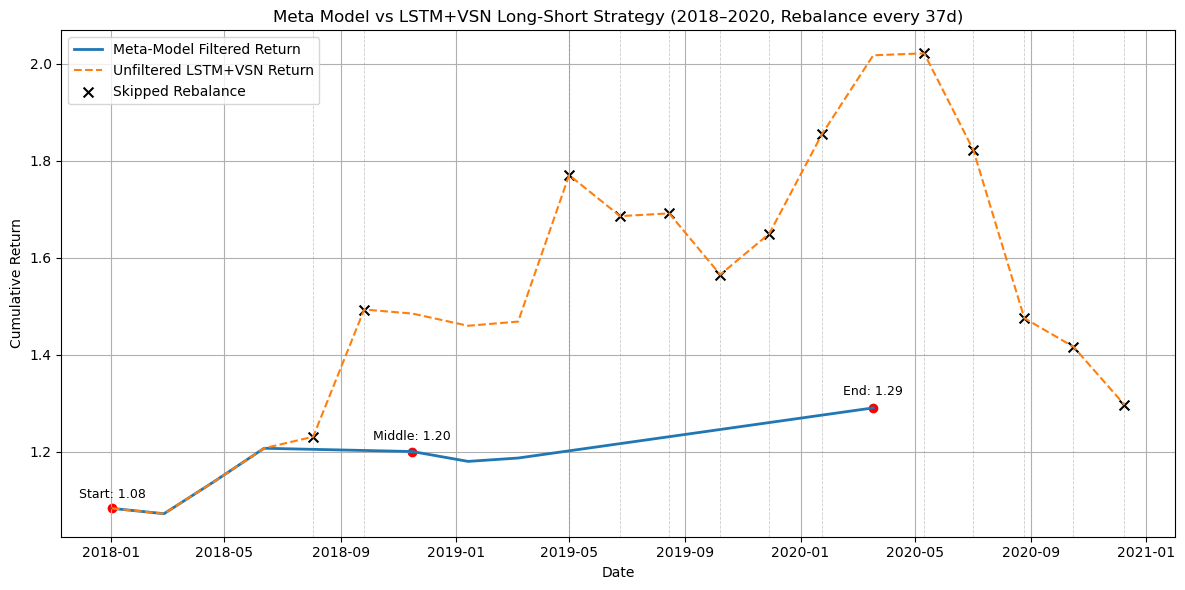

In [20]:
lstm_vsn_df = pd.read_csv("lstm_vsn_train_test_predictions.csv")
lstm_vsn_df['date'] = pd.to_datetime(lstm_vsn_df['date'])
final_test_predictions = pd.read_csv("vsn_lstm_meta_prediction.csv")
final_test_predictions['date'] = pd.to_datetime(final_test_predictions['date'])

# Step 1: Identify rebalance days (2018 to 2020 only)
rebalance_days = lstm_vsn_df[
    (lstm_vsn_df['date'] >= pd.Timestamp("2018-01-01")) &
    (lstm_vsn_df['date'] <= pd.Timestamp("2020-12-31"))
]['date'].drop_duplicates().sort_values().reset_index(drop=True)[::37]

# Step 2: Use meta model to filter rebalance days
meta_threshold = 0.5
active_days = final_test_predictions[
    (final_test_predictions['pred_prob'] > meta_threshold) &
    (final_test_predictions['date'] >= pd.Timestamp("2018-01-01")) &
    (final_test_predictions['date'] <= pd.Timestamp("2020-12-31"))
]['date'].unique()

filtered_rebalance_days = [d for d in rebalance_days if d in active_days]
non_trading_days = [d for d in rebalance_days if d not in active_days]

# Step 3: Backtest for meta-model filtered strategy
meta_bt_results = []

for reb_date in filtered_rebalance_days:
    group = lstm_vsn_df[lstm_vsn_df['date'] == reb_date]

    long_candidates = group[group['pred'] > 0]
    long_group = long_candidates.nlargest(4, 'pred')

    short_candidates = group[group['pred'] < 0]
    short_group = short_candidates.nsmallest(2, 'pred')

    long_return = long_group['true'].mean() if not long_group.empty else 0.0
    short_return = short_group['true'].mean() if not short_group.empty else 0.0
    net_return = long_return - short_return

    meta_bt_results.append({
        'date': reb_date,
        'long_return': long_return,
        'short_return': short_return,
        'net_return': net_return
    })

meta_bt_df = pd.DataFrame(meta_bt_results).sort_values('date')
meta_bt_df[['long_return', 'short_return', 'net_return']] = meta_bt_df[[
    'long_return', 'short_return', 'net_return']].fillna(0.0)
meta_bt_df['cum_return'] = (1 + meta_bt_df['net_return']).cumprod()

# Step 4: Evaluate meta-model strategy
def evaluate_performance(bt_df):
    daily_returns = bt_df['net_return']
    sharpe = daily_returns.mean() / daily_returns.std()* np.sqrt(252 / 40)
    cum_return = bt_df['cum_return'].iloc[-1]
    peak = bt_df['cum_return'].cummax()
    max_dd = ((bt_df['cum_return'] / peak) - 1).min()
    return sharpe, max_dd, cum_return

sharpe_meta, max_dd_meta, final_cumret_meta = evaluate_performance(meta_bt_df)

print(f"Meta Model Sharpe Ratio:            {sharpe_meta:.4f}")
print(f"Meta Model Max Drawdown:            {max_dd_meta:.4f}")
print(f"Meta Model Final Cumulative Return: {final_cumret_meta:.2f}")

# Step 5: Raw backtest using same 2018–2020 window
def backtest_lstm_vsn_every_37_days(df, top_long=4, top_short=2):
    df = df[
        (df['date'] >= pd.Timestamp("2018-01-01")) &
        (df['date'] <= pd.Timestamp("2020-12-31"))
    ].copy()

    all_dates = df['date'].drop_duplicates().sort_values().reset_index(drop=True)
    rebal_dates = all_dates[::37]

    portfolio_returns = []

    for reb_date in rebal_dates:
        group = df[df['date'] == reb_date]

        long_candidates = group[group['pred'] > 0]
        long_group = long_candidates.nlargest(min(top_long, len(long_candidates)), 'pred')
        long_return = long_group['true'].mean() if not long_group.empty else 0.0

        short_candidates = group[group['pred'] < 0]
        short_group = short_candidates.nsmallest(min(top_short, len(short_candidates)), 'pred')
        short_return = short_group['true'].mean() if not short_group.empty else 0.0

        net_return = long_return - short_return

        portfolio_returns.append({
            'date': reb_date,
            'long_return': long_return,
            'short_return': short_return,
            'net_return': net_return
        })

    return pd.DataFrame(portfolio_returns)

raw_bt_df = backtest_lstm_vsn_every_37_days(lstm_vsn_df, top_long=4, top_short=2)
raw_bt_df = raw_bt_df.sort_values('date').copy()
raw_bt_df[['long_return', 'short_return', 'net_return']] = raw_bt_df[[
    'long_return', 'short_return', 'net_return'
]].fillna(0.0)
raw_bt_df['cum_return'] = (1 + raw_bt_df['net_return']).cumprod()

# Step 6: Plot cumulative returns
plt.figure(figsize=(12, 6))

# Meta model return
plt.plot(meta_bt_df['date'], meta_bt_df['cum_return'], label='Meta-Model Filtered Return', linewidth=2)

# Raw LSTM+VSN return
plt.plot(raw_bt_df['date'], raw_bt_df['cum_return'], label='Unfiltered LSTM+VSN Return', linewidth=1.5, linestyle='--')

# Annotate key points
for idx, label in zip([0, len(meta_bt_df) // 2, -1], ['Start', 'Middle', 'End']):
    date = meta_bt_df['date'].iloc[idx]
    val = meta_bt_df['cum_return'].iloc[idx]
    plt.scatter(date, val, color='red')
    plt.text(date, val * 1.02, f'{label}: {val:.2f}', ha='center', fontsize=9)

# Mark skipped overlapping days
plotted_label = False
for d in non_trading_days:
    if pd.Timestamp("2018-01-01") <= d <= pd.Timestamp("2020-12-31"):
        plt.axvline(x=d, color='gray', linestyle='--', linewidth=0.6, alpha=0.4)
        y_val = raw_bt_df.loc[raw_bt_df['date'] == d, 'cum_return']
        if not y_val.empty:
            plt.scatter(d, y_val.values[0], marker='x', color='black', s=50,
                        label='Skipped Rebalance' if not plotted_label else "")
            plotted_label = True

# Final formatting
plt.title("Meta Model vs LSTM+VSN Long-Short Strategy (2018–2020, Rebalance every 37d)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 11. Meta Model-Scaled Portfolio with Risk Control Weighting Strategy

### This section compares the effectiveness of different portfolio weighting schemes — Equal Weight (EQ), Volatility Parity (VP), and Risk Parity (RP)
---

### Weighting Methods

#### Equal Weight

$$
w_i = \frac{1}{N}
$$

All stocks in long/short groups receive equal weights.

#### Volatility Parity

For each stock, volatility over the past 40 days is estimated:

$$
\sigma_i = \text{std}(\log(P_t / P_{t-1}))
$$

Weights are inversely proportional to volatility:

$$
w_i = \frac{1 / \sigma_i}{\sum_j 1 / \sigma_j}
$$

#### Risk Parity

Using the covariance matrix $\Sigma$ of past 40 log returns:

$$
w_i = \frac{1 / \sqrt{\Sigma_{ii}}}{\sum_j 1 / \sqrt{\Sigma_{jj}}}
$$

Weights are normalized within long and short sides separately.

---

## Different Weighted Method Result Analysis


The **Equal Weight** strategy outperformed both **Volatility Parity** and **Risk Parity** across all key metrics:

- **Final cumulative return**: 1.29  
- **Sharpe ratio**: 0.7533  
- **Maximum drawdown**: 2.24%

In comparison:

- **Risk Parity** achieved a final return of 1.28, a Sharpe ratio of 0.6762, and a drawdown of 2.69%.
- **Volatility Parity** delivered a final return of 1.21, a Sharpe ratio of 0.6518, and a drawdown of 3.08%.

**Conclusion**: Equal Weight remains the best weighting method under the current meta model.


| Strategy           | Sharpe Ratio | Max Drawdown | Final Cumulative Return |
|--------------------|--------------|--------------|--------------------------|
| Equal Weight       | 1.8909       | 0.0224       | 1.29                     |
| Volatility Parity  | 1.6359       | 0.0308       | 1.21                     |
| Risk Parity        | 1.6973       | 0.0269       | 1.28                     |


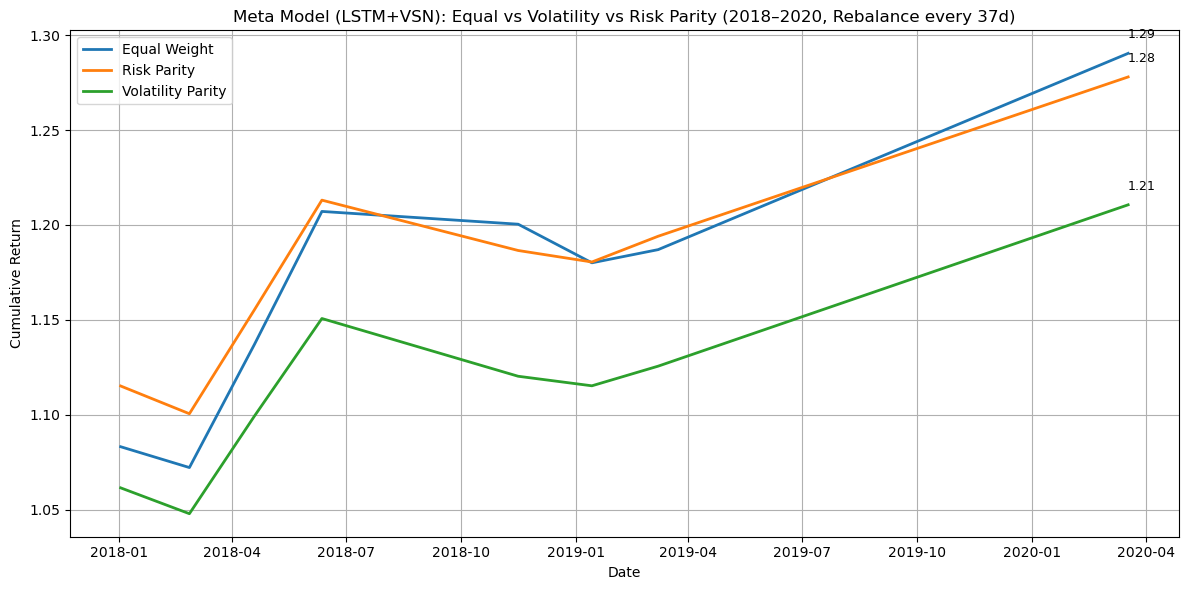

In [21]:
# Load Data
lstm_vsn_df = pd.read_csv("lstm_vsn_train_test_predictions.csv")
lstm_vsn_df['date'] = pd.to_datetime(lstm_vsn_df['date'])

px_df = pd.read_csv("filtered_pxlast_2010_2022.csv")
px_df['date'] = pd.to_datetime(px_df['date'])

final_test_predictions = pd.read_csv("vsn_lstm_meta_prediction.csv")
final_test_predictions['date'] = pd.to_datetime(final_test_predictions['date'])

# Setup
meta_threshold = 0.5
rebalance_days = lstm_vsn_df[
    (lstm_vsn_df['date'] >= "2018-01-01") & (lstm_vsn_df['date'] <= "2020-12-31")
]['date'].drop_duplicates().sort_values().reset_index(drop=True)[::37]

active_days = final_test_predictions[
    (final_test_predictions['pred_prob'] > meta_threshold) &
    (final_test_predictions['date'] >= "2018-01-01") &
    (final_test_predictions['date'] <= "2020-12-31")
]['date'].unique()

filtered_rebalance_days = [d for d in rebalance_days if d in active_days]
all_reb_dates = pd.DatetimeIndex(pd.to_datetime(filtered_rebalance_days), name='date')

meta_bt_results_eq = []
meta_bt_results_vp = []
meta_bt_results_rp = []

# Backtest Loop
for reb_date in filtered_rebalance_days:
    group = lstm_vsn_df[lstm_vsn_df['date'] == reb_date].copy()
    long_group = group[group['pred'] > 0].nlargest(4, 'pred')
    short_group = group[group['pred'] < 0].nsmallest(2, 'pred')
    all_tickers = list(long_group['ticker']) + list(short_group['ticker'])

    # Equal Weight
    long_eq_ret = long_group['true'].mean() if not long_group.empty else 0.0
    short_eq_ret = short_group['true'].mean() if not short_group.empty else 0.0
    net_eq_ret = long_eq_ret - short_eq_ret
    meta_bt_results_eq.append({'date': reb_date, 'net_return': net_eq_ret})

    # Volatility Parity
    def estimate_vol(ticker):
        px = px_df[(px_df['ticker'] == ticker) & (px_df['date'] < reb_date)].sort_values('date').tail(40)
        px_ret = np.log(px['PX_LAST'] / px['PX_LAST'].shift(1)).dropna()
        return px_ret.std() if not px_ret.empty else 1.0

    long_group['vol'] = long_group['ticker'].apply(estimate_vol)
    short_group['vol'] = short_group['ticker'].apply(estimate_vol)
    long_group['weight'] = 1.0 / long_group['vol']
    short_group['weight'] = 1.0 / short_group['vol']
    long_group['weight'] /= long_group['weight'].sum()
    short_group['weight'] /= short_group['weight'].sum()

    long_vp_ret = (long_group['true'] * long_group['weight']).sum()
    short_vp_ret = (short_group['true'] * short_group['weight']).sum()
    net_vp_ret = long_vp_ret - short_vp_ret
    meta_bt_results_vp.append({'date': reb_date, 'net_return': net_vp_ret})

    # Risk Parity
    try:
        px_slice = px_df[(px_df['ticker'].isin(all_tickers)) & (px_df['date'] <= reb_date)]
        px_pivot = px_slice.pivot(index='date', columns='ticker', values='PX_LAST').sort_index()
        px_window = px_pivot.tail(40)
        ret_mat = np.log(px_window / px_window.shift(1)).dropna()
        cov_matrix = ret_mat.cov()

        inv_vol = 1.0 / np.sqrt(np.diag(cov_matrix))
        inv_vol = pd.Series(inv_vol, index=cov_matrix.columns)

        long_weights = inv_vol[long_group['ticker']] / inv_vol[long_group['ticker']].sum()
        short_weights = inv_vol[short_group['ticker']] / inv_vol[short_group['ticker']].sum()

        long_returns = long_group.set_index('ticker').loc[long_weights.index]['true']
        short_returns = short_group.set_index('ticker').loc[short_weights.index]['true']

        net_rp_ret = (long_returns * long_weights).sum() - (short_returns * short_weights).sum()
    except:
        net_rp_ret = 0.0

    meta_bt_results_rp.append({'date': reb_date, 'net_return': net_rp_ret})

# Build Cumulative Return DataFrames
def build_cum_return_df(bt_result_list, label, all_dates):
    df_bt = pd.DataFrame(bt_result_list)
    df_bt['date'] = pd.to_datetime(df_bt['date'])
    df_bt = df_bt.set_index('date').reindex(all_dates)  
    df_bt['net_return'] = df_bt['net_return'].fillna(0.0)
    df_bt = df_bt.reset_index().sort_values('date')
    df_bt['cum_return'] = (1 + df_bt['net_return']).cumprod()
    df_bt['strategy'] = label
    return df_bt[['date', 'cum_return', 'strategy', 'net_return']]

df_eq = build_cum_return_df(meta_bt_results_eq, 'Equal Weight', all_reb_dates)
df_vp = build_cum_return_df(meta_bt_results_vp, 'Volatility Parity', all_reb_dates)
df_rp = build_cum_return_df(meta_bt_results_rp, 'Risk Parity', all_reb_dates)

plot_df = pd.concat([df_eq, df_vp, df_rp], axis=0)

# Evaluation
def evaluate(df):
    sharpe = df['net_return'].mean() / df['net_return'].std() * np.sqrt(252 / 40) if df['net_return'].std() > 0 else 0.0
    cum = df['cum_return'].iloc[-1]
    hwm = df['cum_return'].cummax()
    dd = 1 - df['cum_return'] / hwm
    mdd = dd.max()
    return sharpe, mdd, cum

metrics = []
for name, df_strategy in zip(['Equal Weight', 'Volatility Parity', 'Risk Parity'], [df_eq, df_vp, df_rp]):
    s, mdd, cumret = evaluate(df_strategy)
    metrics.append({
        'Strategy': name,
        'Sharpe': round(s, 4),
        'Max DD': round(mdd, 4),
        'Final Return': round(cumret, 2)
    })

# Print Metrics Table
print("\n| Strategy           | Sharpe Ratio | Max Drawdown | Final Cumulative Return |")
print("|--------------------|--------------|--------------|--------------------------|")
for row in metrics:
    print(f"| {row['Strategy']:<18} | {row['Sharpe']:<12} | {row['Max DD']:<12} | {row['Final Return']:<24} |")

plt.figure(figsize=(12, 6))

for label, group in plot_df.groupby('strategy'):
    plt.plot(group['date'], group['cum_return'], label=label, linewidth=2)

    end_date = group['date'].iloc[-1]
    end_val = group['cum_return'].iloc[-1]

    plt.text(end_date, end_val * 1.005, f'{end_val:.2f}', fontsize=9, ha='left', va='bottom')

plt.title("Meta Model (LSTM+VSN): Equal vs Volatility vs Risk Parity (2018–2020, Rebalance every 37d)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()